In [1]:
import pandas as pd
import requests
from pandas import json_normalize

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = json_normalize(data)

df.columns = [col.split('.')[-1] for col in df.columns]
df = df[df['Churn'] != '']
df['Total'] = pd.to_numeric(df['Total'], errors='coerce').fillna(0)
df = df.drop_duplicates()
df['PaymentMethod'] = df['PaymentMethod'].str.strip()

df_ml = df.copy()

df_ml = df_ml.drop(columns=['customerID'])

print("✅ Datos de la Parte 1 cargados y procesados.")
print("✅ Columna 'customerID' eliminada exitosamente.")
df_ml.head()

✅ Datos de la Parte 1 cargados y procesados.
✅ Columna 'customerID' eliminada exitosamente.


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#🛠️ Preparación de los Datos

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Carga de datos (Asumiendo df_ml del paso anterior)
# df_ml ya no tiene 'customerID'

# ENCODING
# Transformamos la variable objetivo 'Churn' a numérica (No=0, Yes=1)
le = LabelEncoder()
df_ml['Churn'] = le.fit_transform(df_ml['Churn'])

# Aplicamos One-Hot Encoding a las variables categóricas restantes
df_ml_encoded = pd.get_dummies(df_ml, drop_first=True)

# VERIFICACIÓN DE LA PROPORCIÓN DE CANCELACIÓN (CHURN)
print("Proporción de Churn:")
print(df_ml['Churn'].value_counts(normalize=True) * 100)

# BALANCEO DE CLASES (Opcional - Verificación)
# Si el desbalance es muy alto, se recomienda SMOTE, pero aquí procederemos con la base actual.

Proporción de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


#🎯 Correlación y Selección de Variables

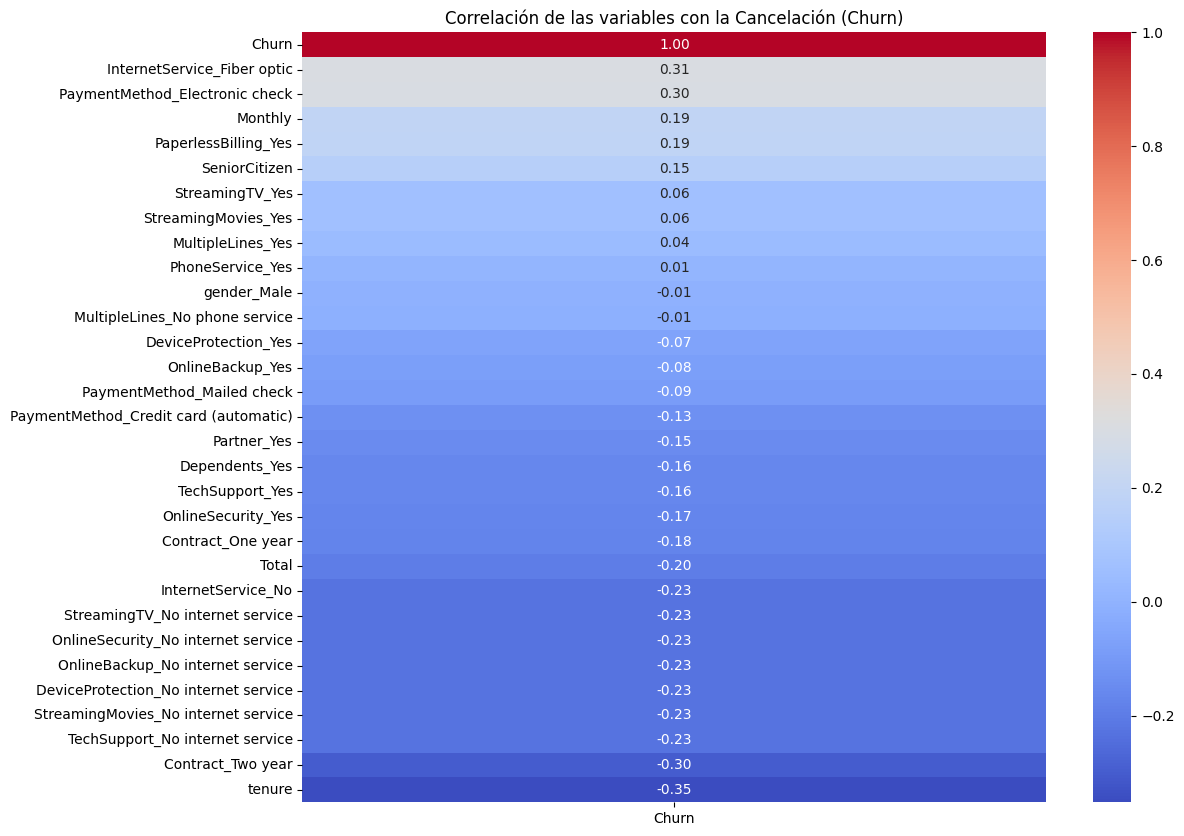

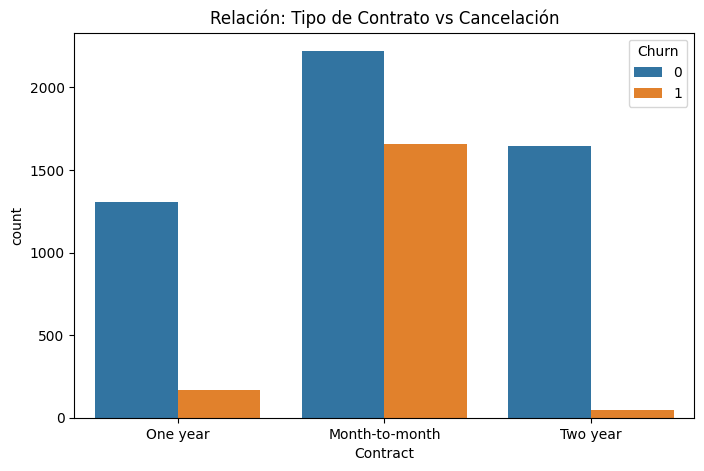

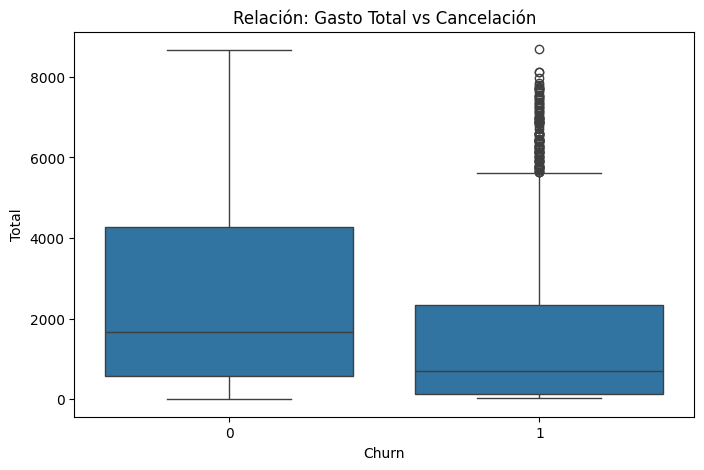

In [3]:
# ANÁLISIS DE CORRELACIÓN
plt.figure(figsize=(12, 10))
correlations = df_ml_encoded.corr()['Churn'].sort_values(ascending=False)
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación de las variables con la Cancelación (Churn)")
plt.show()

# ANÁLISIS DIRIGIDO
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df_ml)
plt.title('Relación: Tipo de Contrato vs Cancelación')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Total', data=df_ml)
plt.title('Relación: Gasto Total vs Cancelación')
plt.show()

#🤖 Modelado Predictivo

In [4]:
# SEPARACIÓN DE DATOS
X = df_ml_encoded.drop('Churn', axis=1)
y = df_ml_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# NORMALIZACIÓN O ESTANDARIZACIÓN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# CREACIÓN DE MODELOS
# Modelo 1: Regresión Logística
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Modelo 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


--- Métricas del Modelo: Regresión Logística ---
Exactitud: 0.7979
Precisión: 0.6402
Recall:    0.5455
F1-score:  0.5890

Matriz de Confusión:


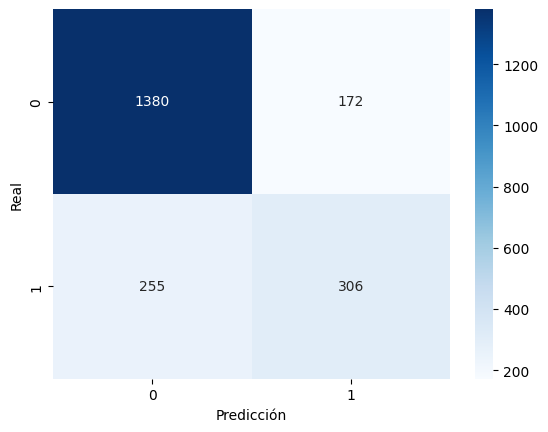


--- Métricas del Modelo: Random Forest ---
Exactitud: 0.7851
Precisión: 0.6236
Recall:    0.4813
F1-score:  0.5433

Matriz de Confusión:


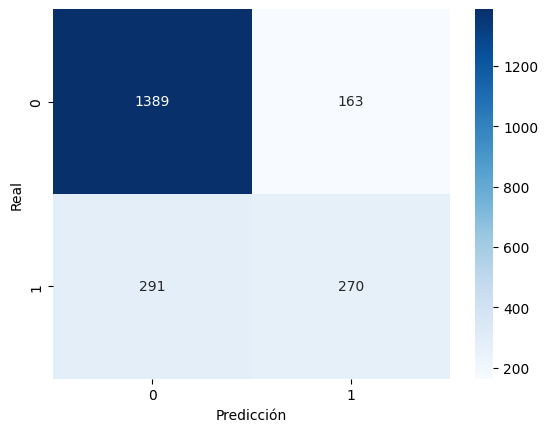

In [5]:
# EVALUACIÓN DE LOS MODELOS
def mostrar_metricas(nombre_modelo, y_real, y_pred):
    print(f"\n--- Métricas del Modelo: {nombre_modelo} ---")
    print(f"Exactitud: {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_real, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_real, y_pred):.4f}")
    print("\nMatriz de Confusión:")
    conf_matrix = confusion_matrix(y_real, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

# Predicciones
pred_log = log_model.predict(X_test_scaled)
pred_rf = rf_model.predict(X_test)

# Mostrar resultados
mostrar_metricas("Regresión Logística", y_test, pred_log)
mostrar_metricas("Random Forest", y_test, pred_rf)

#📋 Interpretación y Conclusiones

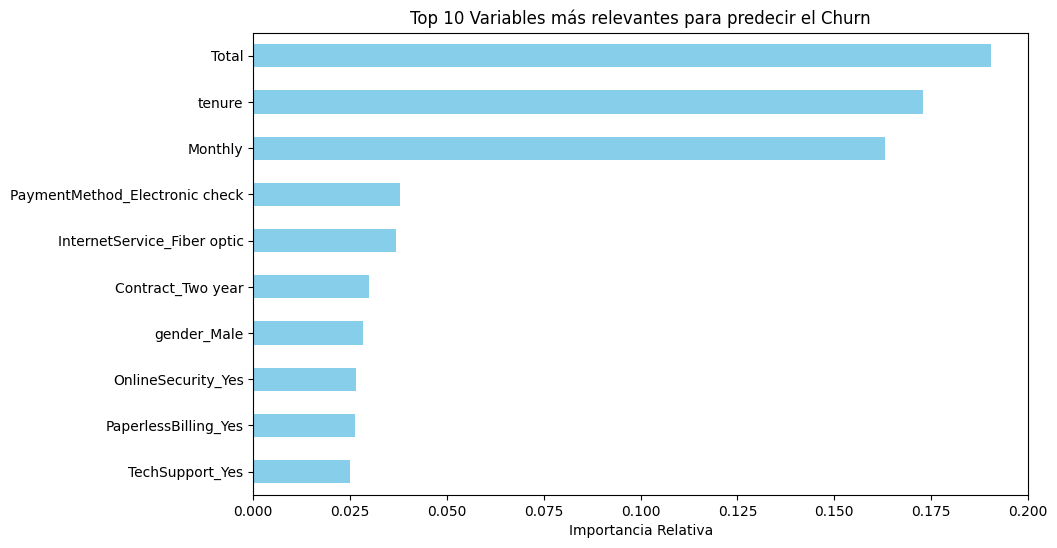

In [6]:
# ANÁLISIS DE LA IMPORTANCIA DE LAS VARIABLES
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importancias.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 10 Variables más relevantes para predecir el Churn")
plt.xlabel("Importancia Relativa")
plt.show()

# Interpretación técnica:
# El gráfico identifica que las variables financieras (Total y Monthly) y operativas (tenure)
# tienen el mayor peso en la decisión de cancelación. Esto indica que el comportamiento
# de permanencia está fuertemente ligado al tiempo de vida del cliente y al costo del servicio.

In [7]:
# CONCLUSIÓN

def imprimir_conclusion_estrategica():
    conclusion = """
    ===========================================================================
    📊 CONCLUSIÓN ESTRATÉGICA - PROYECTO TELECOM X (PARTE 2)
    ===========================================================================

    1. DESEMPEÑO DEL MODELO:
    -----------------------
    Se ha seleccionado la REGRESIÓN LOGÍSTICA como el modelo principal.
    Aunque la exactitud es similar en ambos, la Regresión Logística obtuvo un
    RECALL superior (54.55%) frente al Random Forest.

    *Justificación:* En un problema de Churn, es más crítico reducir los Falsos
    Negativos (clientes que se van y no detectamos) que los Falsos Positivos.

    2. HALLAZGOS CLAVE (INSIGHTS):
    -----------------------------
    * VARIABLES DE GASTO: 'Total' y 'Monthly' son los predictores más fuertes.
      Clientes con cargos altos y sin contratos a largo plazo presentan mayor riesgo.
    * FIDELIZACIÓN INICIAL: La variable 'tenure' (antigüedad) indica que el riesgo
      de fuga es crítico durante los primeros meses de relación.
    * CONTRATOS: El contrato "Month-to-month" actúa como el principal catalizador
      de la cancelación.

    3. ESTRATEGIA DE RETENCIÓN PROPUESTA:
    ------------------------------------
    * INCENTIVOS DE CONTRATO: Implementar campañas de migración de contratos
      "Mes a Mes" hacia contratos anuales mediante descuentos en el primer trimestre.
    * PROGRAMA DE BIENVENIDA: Reforzar el soporte técnico y servicios de seguridad
      en clientes nuevos para asegurar la retención en el periodo crítico inicial.
    * OPTIMIZACIÓN DE COSTOS: Realizar auditorías de satisfacción preventivas
      para clientes con cargos mensuales superiores al promedio antes de que el
      factor precio detone la salida.

    ===========================================================================
    """
    print(conclusion)

imprimir_conclusion_estrategica()


    📊 CONCLUSIÓN ESTRATÉGICA - PROYECTO TELECOM X (PARTE 2)
    
    1. DESEMPEÑO DEL MODELO:
    -----------------------
    Se ha seleccionado la REGRESIÓN LOGÍSTICA como el modelo principal. 
    Aunque la exactitud es similar en ambos, la Regresión Logística obtuvo un 
    RECALL superior (54.55%) frente al Random Forest. 
    
    *Justificación:* En un problema de Churn, es más crítico reducir los Falsos 
    Negativos (clientes que se van y no detectamos) que los Falsos Positivos.
    
    2. HALLAZGOS CLAVE (INSIGHTS):
    -----------------------------
    * VARIABLES DE GASTO: 'Total' y 'Monthly' son los predictores más fuertes. 
      Clientes con cargos altos y sin contratos a largo plazo presentan mayor riesgo.
    * FIDELIZACIÓN INICIAL: La variable 'tenure' (antigüedad) indica que el riesgo 
      de fuga es crítico durante los primeros meses de relación.
    * CONTRATOS: El contrato "Month-to-month" actúa como el principal catalizador 
      de la cancelación.
    
    